# Modelamiento y Validación — Segunda Entrega (Fase 2)

**Proyecto Integrador:** Detección de *Population Drift* en modelos de predicción de gravedad clínica de COVID-19 en Colombia  
**Asignatura:** Machine Learning II — Universidad Externado de Colombia  
**Integrantes:** Ailyn Sofía Gómez Rodríguez, Juan Tomás Rincón Pinzón  
**Docente:** Wilmer Darío Pineda Ríos  

Este notebook ejecuta el flujo completo de la Fase 2:
1. **Réplica del artículo base (*Jones & Farrow, 2025*):** Validación sobre el dataset Wisconsin Breast Cancer con filtro de colinealidad (|r| > 0.90) y 5 semillas.
2. **Simulación fundamentada en Colombia:** Modelamiento de drift de envejecimiento anclado en adultos mayores (p99 + 0.4σ) con ruidos del 5%, 10% y 30%.
3. **Flujo reproducible sin fuga de datos:** Integración en `Pipeline` y `ColumnTransformer` ajustado estrictamente dentro de cada partición/fold.
4. **Monitoreo con OCSVM e Isolation Forest:** Submuestreo no supervisado de 5.000 filas de 2020 para entrenamiento, evaluación de falsa alarma *out-of-sample* (95.000 filas restantes de 2020), olas 2021/2022 y simulaciones; análisis de sensibilidad de $\nu$.
5. **Modelado supervisado de gravedad:** Línea base (Mayoría), Regresión Logística, Random Forest, XGBoost, LightGBM y SVM-RBF real.
6. **Validación rigurosa:** `GridSearchCV` estratificado (k=5), **Validación Cruzada Anidada (*Nested CV*)**, optimización de umbral de decisión y reporte de métricas con variabilidad ($	ext{media} \pm 	ext{std}$).
7. **Evaluación temporal fuera de muestra (2021 y 2022):** Diagnóstico de *Covariate Drift* vs. *Prevalence Drift* mediante tests de Kolmogorov-Smirnov y ratios de AUC-PR / prevalencia.
8. **Interpretación clínica:** Importancia por permutación, curvas PR y ROC, matrices de confusión y análisis de errores.


In [1]:
# --- 1. Configuración, Imports y Semilla ---
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC, OneClassSVM
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (f1_score, precision_score, recall_score, roc_auc_score,
                             average_precision_score, confusion_matrix, roc_curve,
                             precision_recall_curve, brier_score_loss, classification_report)
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb

SEED = 42
np.random.seed(SEED)

# Detección robusta de rutas
if os.path.exists("../data/processed/dataset_reducido.csv"):
    BASE = os.path.abspath("..")
elif os.path.exists("data/processed/dataset_reducido.csv"):
    BASE = os.path.abspath(".")
else:
    BASE = os.path.abspath("Entrega2")

DATA_PATH = os.path.join(BASE, "data", "processed", "dataset_reducido.csv")
FIG_DIR = os.path.join(BASE, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'


In [2]:
# --- 2. Carga y Verificación del Dataset Consolidado ---
df = pd.read_csv(DATA_PATH)
print(f"Forma total del dataset reducido: {df.shape}")
print("\nDistribución por ola epidemiológica:")
print(df.groupby('ola')['grave'].agg(
    total='count',
    graves='sum',
    tasa_base=lambda x: f"{x.mean()*100:.2f}%"
))

df_2020 = df[df['ola'] == '2020 (original)'].reset_index(drop=True)
df_2021 = df[df['ola'] == '2021 (Delta)'].reset_index(drop=True)
df_2022 = df[df['ola'] == '2022 (Omicron)'].reset_index(drop=True)


Forma total del dataset reducido: (300000, 14)

Distribución por ola epidemiológica:
                  total  graves tasa_base
ola                                      
2020 (original)  100000    2821     2.82%
2021 (Delta)     100000    2327     2.33%
2022 (Omicron)   100000    1098     1.10%


In [3]:
# --- 3. Réplica Formal del Paper (Wisconsin Breast Cancer - Jones & Farrow 2025) ---
data_w = load_breast_cancer()
X_w = pd.DataFrame(data_w.data, columns=data_w.feature_names)
y_w = data_w.target

# Filtro secuencial de colinealidad (|r| > 0.90) para eliminar 9 variables redundantes -> 21 variables
corr_w = X_w.corr().abs()
dropped_w = set()
for i in range(len(corr_w.columns)):
    c1 = corr_w.columns[i]
    if c1 in dropped_w:
        continue
    for j in range(i + 1, len(corr_w.columns)):
        c2 = corr_w.columns[j]
        if c2 in dropped_w:
            continue
        if corr_w.iloc[i, j] > 0.90:
            dropped_w.add(c2)

X_w_filt = X_w.drop(columns=list(dropped_w))
print(f"Variables seleccionadas tras filtro de colinealidad: {X_w_filt.shape[1]} (eliminadas {len(dropped_w)})")

# SMOTE hasta 714 y escalamiento
smote_w = SMOTE(random_state=SEED)
X_w_res, y_w_res = smote_w.fit_resample(X_w_filt, y_w)
scaler_w = StandardScaler()
X_w_scaled = scaler_w.fit_transform(X_w_res)

ocsvm_w = OneClassSVM(kernel='rbf', gamma='auto', nu=0.01)
ocsvm_w.fit(X_w_scaled)

rad_idx = X_w_filt.columns.get_loc('mean radius') if 'mean radius' in X_w_filt.columns else 0
noise_levels = [0.05, 0.10, 0.30]
seeds_w = [42, 101, 2024, 7, 99]

print("\nResultados de la réplica en Wisconsin (promedio sobre 5 semillas):")
print(f"{'Nivel Ruido':12s} | {'Inliers Paper':15s} | {'Nuestra Réplica (Inliers)':25s} | {'Outliers Réplica':15s}")
print("-" * 75)
for noise in noise_levels:
    in_rates = []
    for s in seeds_w:
        np.random.seed(s)
        base_i = np.random.choice(len(X_w_res), size=10000, replace=True)
        X_s = np.array(X_w_res.iloc[base_i].values, copy=True, dtype=np.float64)
        X_s[:, rad_idx] += 0.4 * np.std(X_w_res.iloc[:, rad_idx])
        X_s += np.random.normal(0, noise * np.std(X_w_res.values, axis=0), size=X_s.shape)
        p = ocsvm_w.predict(scaler_w.transform(X_s))
        in_rates.append(np.mean(p == 1))
    
    m_in = np.mean(in_rates)
    s_in = np.std(in_rates)
    paper_val = "0.27%" if noise==0.05 else ("4.86%" if noise==0.10 else "8.51%")
    print(f"{int(noise*100):3d}% {'ruido':6s} | {paper_val:15s} | {m_in*100:6.2f}% +- {s_in*100:4.2f}%       | {(1-m_in)*100:6.2f}%")


Variables seleccionadas tras filtro de colinealidad: 21 (eliminadas 9)

Resultados de la réplica en Wisconsin (promedio sobre 5 semillas):
Nivel Ruido  | Inliers Paper   | Nuestra Réplica (Inliers) | Outliers Réplica
---------------------------------------------------------------------------


  5% ruido  | 0.27%           |  92.08% +- 0.39%       |   7.92%


 10% ruido  | 4.86%           |  91.31% +- 0.48%       |   8.69%


 30% ruido  | 8.51%           |  84.39% +- 0.44%       |  15.61%


Población base (2020 Train): Media=39.87 años, Desv=17.98 años, Percentil 99=85.00 años


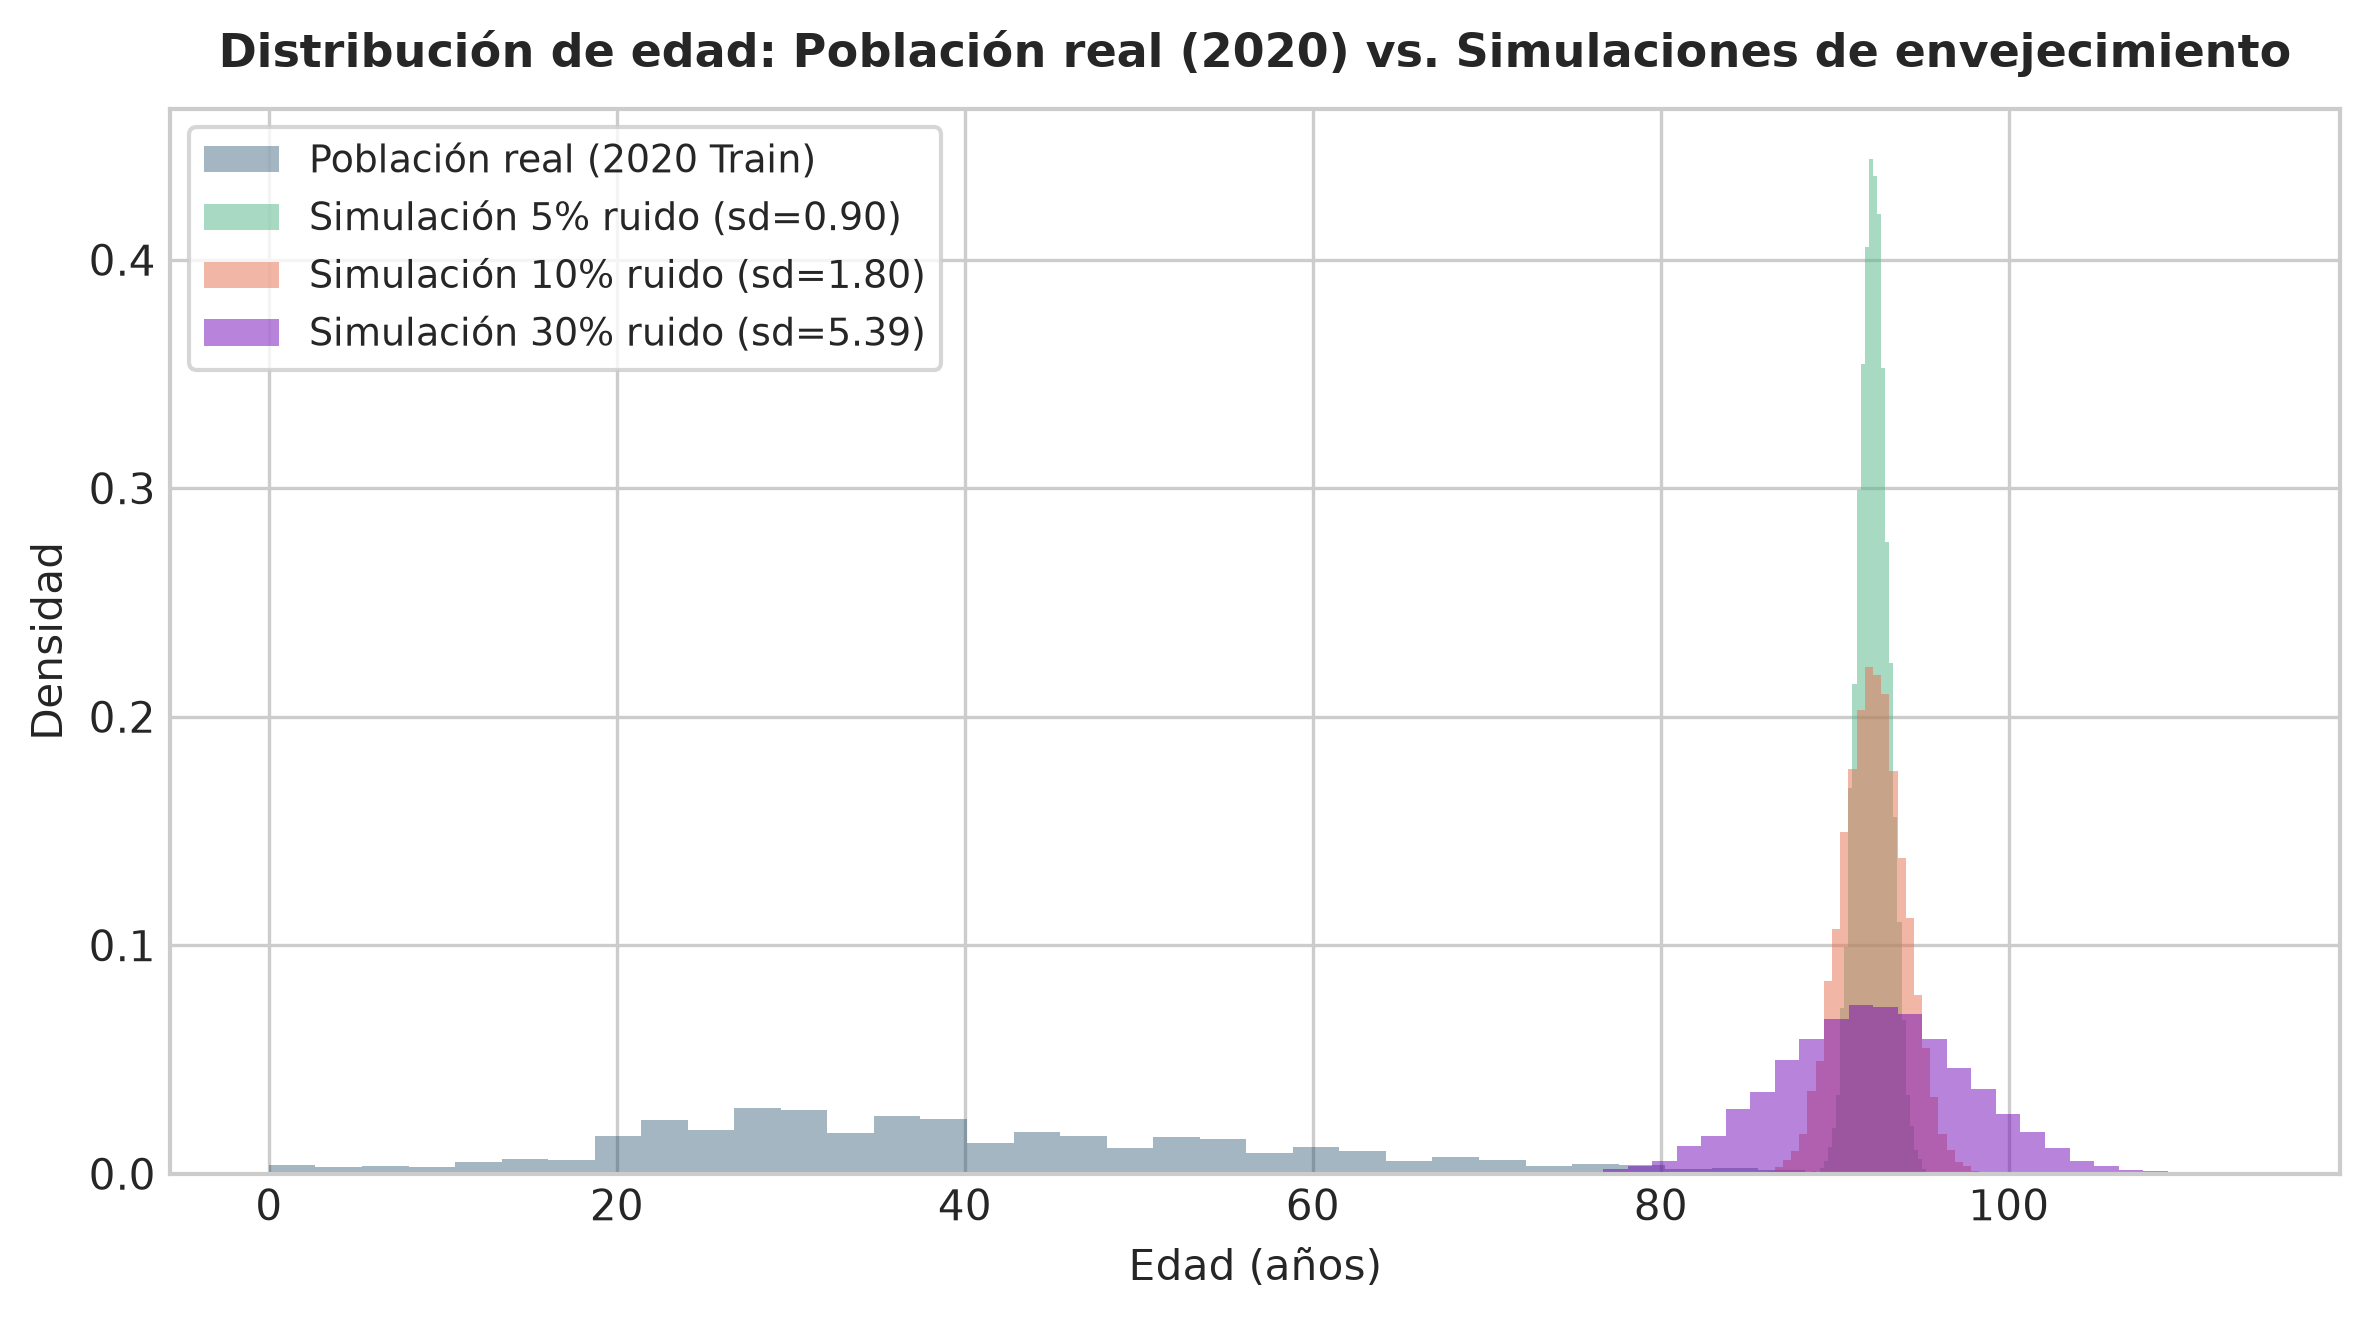


Verificación estadística de la estructura simulada (Criterio 7.1):
           Población Media Desv. Std   P5  P50   P95
   2020 Train (Real) 39.87     17.98 14.0 37.0  73.0
 Simulación 5% ruido 92.19      0.90 90.7 92.2  93.7
Simulación 10% ruido 92.19      1.80 89.2 92.2  95.1
Simulación 30% ruido 92.18      5.41 83.3 92.2 101.1


In [4]:
# --- 4. Simulación Fundamentada en Contexto Colombiano ---
age_train = df_2020['edad_anios'].values
mu_age = np.mean(age_train)
std_age = np.std(age_train)
p99_age = np.percentile(age_train, 99)

print(f"Población base (2020 Train): Media={mu_age:.2f} años, Desv={std_age:.2f} años, Percentil 99={p99_age:.2f} años")

center_drift = p99_age + 0.4 * std_age
sim_data = {}
sim_stats = []

sim_stats.append({
    "Población": "2020 Train (Real)",
    "Media": f"{mu_age:.2f}",
    "Desv. Std": f"{std_age:.2f}",
    "P5": f"{np.percentile(age_train, 5):.1f}",
    "P50": f"{np.percentile(age_train, 50):.1f}",
    "P95": f"{np.percentile(age_train, 95):.1f}"
})

fig, ax = plt.subplots(figsize=(8, 4.5), dpi=300)
ax.hist(age_train, bins=40, density=True, alpha=0.4, color='#1b4965', label='Población real (2020 Train)')
colors = ['#52b788', '#e76f51', '#7209b7']

for noise, color in zip(noise_levels, colors):
    np.random.seed(SEED)
    sd_noise = noise * std_age
    sim_ages = np.random.normal(center_drift, sd_noise, size=10000)
    sim_ages = np.clip(sim_ages, 0, 115)
    sim_data[f"{int(noise*100)}%"] = sim_ages
    sim_stats.append({
        "Población": f"Simulación {int(noise*100)}% ruido",
        "Media": f"{np.mean(sim_ages):.2f}",
        "Desv. Std": f"{np.std(sim_ages):.2f}",
        "P5": f"{np.percentile(sim_ages, 5):.1f}",
        "P50": f"{np.percentile(sim_ages, 50):.1f}",
        "P95": f"{np.percentile(sim_ages, 95):.1f}"
    })
    ax.hist(sim_ages, bins=30, density=True, alpha=0.5, color=color,
            label=f'Simulación {int(noise*100)}% ruido (sd={sd_noise:.2f})')

ax.set_title('Distribución de edad: Población real (2020) vs. Simulaciones de envejecimiento', fontsize=11, fontweight='bold', pad=10)
ax.set_xlabel('Edad (años)', fontsize=10)
ax.set_ylabel('Densidad', fontsize=10)
ax.legend(frameon=True, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "verificacion_simulacion.png"), dpi=300)
plt.show()

print("\nVerificación estadística de la estructura simulada (Criterio 7.1):")
print(pd.DataFrame(sim_stats).to_string(index=False))


In [5]:
# --- 5. OCSVM como Capa de Monitoreo y Evaluación Out-of-Sample ---
# Submuestreo NO supervisado de 5.000 casos de 2020 para entrenamiento
np.random.seed(SEED)
idx_2020_all = np.arange(len(df_2020))
np.random.shuffle(idx_2020_all)
idx_ocsvm_train = idx_2020_all[:5000]
idx_ocsvm_test = idx_2020_all[5000:]  # 95.000 casos restantes para medir falsa alarma out-of-sample

features = ['edad_anios', 'sexo', 'ciudad_top', 'fuente_tipo_contagio']
numeric_cols = ['edad_anios']
categorical_cols = ['sexo', 'ciudad_top', 'fuente_tipo_contagio']

preproc_ocsvm = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
])

X_tr_proc = preproc_ocsvm.fit_transform(df_2020.iloc[idx_ocsvm_train][features])
X_te_proc = preproc_ocsvm.transform(df_2020.iloc[idx_ocsvm_test][features])
X_21_proc = preproc_ocsvm.transform(df_2021[features])
X_22_proc = preproc_ocsvm.transform(df_2022[features])

ocsvm_col = OneClassSVM(kernel='rbf', gamma='auto', nu=0.01).fit(X_tr_proc)
iforest_col = IsolationForest(contamination=0.01, random_state=SEED).fit(X_tr_proc)

sim_pops_proc = {}
for n_k, ages in sim_data.items():
    s_df = pd.DataFrame({'edad_anios': ages, 'sexo': 'M', 'ciudad_top': 'Bogota', 'fuente_tipo_contagio': 'Comunitaria'})
    sim_pops_proc[n_k] = preproc_ocsvm.transform(s_df)

eval_pops = {
    "2020 Train (In-sample, 5k)": X_tr_proc,
    "2020 Test (Out-of-sample, 95k)": X_te_proc,
    "2021 Delta (100k)": X_21_proc,
    "2022 Ómicron (100k)": X_22_proc,
    "Sim 5% ruido (10k)": sim_pops_proc["5%"],
    "Sim 10% ruido (10k)": sim_pops_proc["10%"],
    "Sim 30% ruido (10k)": sim_pops_proc["30%"]
}

print(f"{'Población Evaluada':35s} | {'OCSVM % Inliers':18s} | {'Isolation Forest % Inliers':25s}")
print("-" * 85)
for name, pop in eval_pops.items():
    in_o = np.mean(ocsvm_col.predict(pop) == 1) * 100
    in_i = np.mean(iforest_col.predict(pop) == 1) * 100
    print(f"{name:35s} | {in_o:15.2f}% | {in_i:22.2f}%")

# Sensibilidad de nu
print("\nSensibilidad del parámetro nu en OCSVM:")
for nu_val in [0.01, 0.05, 0.10]:
    m_nu = OneClassSVM(kernel='rbf', gamma='auto', nu=nu_val).fit(X_tr_proc)
    fa_out = np.mean(m_nu.predict(X_te_proc) == 1) * 100
    det_s30 = np.mean(m_nu.predict(sim_pops_proc["30%"]) == 1) * 100
    print(f"  nu = {nu_val:4.2f} -> Inliers 2020 Test (1 - Falsa Alarma): {fa_out:6.2f}% | Inliers Sim 30% Drift: {det_s30:6.2f}%")


Población Evaluada                  | OCSVM % Inliers    | Isolation Forest % Inliers
-------------------------------------------------------------------------------------
2020 Train (In-sample, 5k)          |           99.00% |                  99.00%


2020 Test (Out-of-sample, 95k)      |           98.96% |                  98.93%


2021 Delta (100k)                   |           99.08% |                  98.08%


2022 Ómicron (100k)                 |           97.99% |                  98.92%
Sim 5% ruido (10k)                  |           99.97% |                 100.00%
Sim 10% ruido (10k)                 |           95.94% |                 100.00%
Sim 30% ruido (10k)                 |           72.00% |                 100.00%

Sensibilidad del parámetro nu en OCSVM:


  nu = 0.01 -> Inliers 2020 Test (1 - Falsa Alarma):  98.96% | Inliers Sim 30% Drift:  72.00%


  nu = 0.05 -> Inliers 2020 Test (1 - Falsa Alarma):  95.16% | Inliers Sim 30% Drift:   9.30%


  nu = 0.10 -> Inliers 2020 Test (1 - Falsa Alarma):  89.89% | Inliers Sim 30% Drift:   0.68%


In [6]:
# --- 6. Modelamiento Supervisado de Gravedad Clínica ---
X_train = df_2020[features]
y_train = df_2020['grave'].values
X_2021 = df_2021[features]
y_2021 = df_2021['grave'].values
X_2022 = df_2022[features]
y_2022 = df_2022['grave'].values

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
])

scale_pos = (len(y_train) - sum(y_train)) / sum(y_train)

models = {
    "Reg. Logística": (
        LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED),
        {'clf__C': [0.01, 0.1, 1.0, 10.0]}
    ),
    "Random Forest": (
        RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1),
        {'clf__n_estimators': [100, 200], 'clf__max_depth': [6, 10]}
    ),
    "XGBoost": (
        xgb.XGBClassifier(scale_pos_weight=scale_pos, eval_metric='logloss', random_state=SEED, n_jobs=-1),
        {'clf__n_estimators': [100, 150], 'clf__max_depth': [3, 5], 'clf__learning_rate': [0.05, 0.1]}
    ),
    "LightGBM": (
        lgb.LGBMClassifier(class_weight='balanced', verbose=-1, random_state=SEED, n_jobs=-1),
        {'clf__n_estimators': [100, 150], 'clf__num_leaves': [15, 31], 'clf__learning_rate': [0.05, 0.1]}
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_summary = []
best_estimators = {}

print("Ajustando hiperparámetros con GridSearchCV (CV estratificada k=5)...")
for name, (clf, p_grid) in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    grid = GridSearchCV(pipe, p_grid, cv=cv, scoring='average_precision', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_pipe = grid.best_estimator_
    best_estimators[name] = best_pipe
    
    # 5-fold CV con métricas de variabilidad
    scores_ap, scores_roc, scores_f1_05, scores_f1_opt = [], [], [], []
    for tr_i, val_i in cv.split(X_train, y_train):
        m = Pipeline([('prep', preprocessor), ('clf', clf.__class__(**{k.replace('clf__', ''): v for k, v in grid.best_params_.items()}))])
        m.fit(X_train.iloc[tr_i], y_train[tr_i])
        probs = m.predict_proba(X_train.iloc[val_i])[:, 1]
        
        scores_ap.append(average_precision_score(y_train[val_i], probs))
        scores_roc.append(roc_auc_score(y_train[val_i], probs))
        scores_f1_05.append(f1_score(y_train[val_i], (probs >= 0.5).astype(int)))
        
        pr, rc, th = precision_recall_curve(y_train[val_i], probs)
        f1_c = 2 * (pr * rc) / (pr + rc + 1e-10)
        opt_t = th[min(np.argmax(f1_c), len(th)-1)]
        scores_f1_opt.append(f1_score(y_train[val_i], (probs >= opt_t).astype(int)))
        
    cv_summary.append({
        "Modelo": name,
        "Mejores Parámetros": str(grid.best_params_),
        "AUC-PR (media +- std)": f"{np.mean(scores_ap):.3f} +- {np.std(scores_ap):.3f}",
        "ROC-AUC (media +- std)": f"{np.mean(scores_roc):.3f} +- {np.std(scores_roc):.3f}",
        "F1 (umbral 0.5)": f"{np.mean(scores_f1_05):.3f} +- {np.std(scores_f1_05):.3f}",
        "F1 (umbral óptimo)": f"{np.mean(scores_f1_opt):.3f} +- {np.std(scores_f1_opt):.3f}"
    })

# Línea base Mayoría
dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
dummy_probs = dummy.predict_proba(X_train)[:, 1]
cv_summary.append({
    "Modelo": "Línea Base (Mayoría)",
    "Mejores Parámetros": "N/A",
    "AUC-PR (media +- std)": f"{average_precision_score(y_train, dummy_probs):.3f} +- 0.000",
    "ROC-AUC (media +- std)": "0.500 +- 0.000",
    "F1 (umbral 0.5)": "0.000 +- 0.000",
    "F1 (umbral óptimo)": "0.000 +- 0.000"
})

df_cv = pd.DataFrame(cv_summary)
print("\nResultados de Validación Cruzada (CV k=5 con variabilidad, Criterio 7.4):")
print(df_cv.to_string(index=False))


Ajustando hiperparámetros con GridSearchCV (CV estratificada k=5)...



Resultados de Validación Cruzada (CV k=5 con variabilidad, Criterio 7.4):
              Modelo                                                            Mejores Parámetros AUC-PR (media +- std) ROC-AUC (media +- std) F1 (umbral 0.5) F1 (umbral óptimo)
      Reg. Logística                                                               {'clf__C': 0.1}        0.268 +- 0.015         0.909 +- 0.003  0.090 +- 0.020     0.351 +- 0.016
       Random Forest                              {'clf__max_depth': 10, 'clf__n_estimators': 200}        0.252 +- 0.014         0.904 +- 0.004  0.023 +- 0.007     0.337 +- 0.020
             XGBoost    {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 150}        0.265 +- 0.020         0.908 +- 0.003  0.055 +- 0.019     0.350 +- 0.018
            LightGBM {'clf__learning_rate': 0.05, 'clf__n_estimators': 150, 'clf__num_leaves': 15}        0.266 +- 0.016         0.907 +- 0.002  0.027 +- 0.012     0.347 +- 0.020
Línea Base (Mayoría)          

In [7]:
# --- 7. Validación Cruzada Anidada (Nested CV: 5 outer x 3 inner, Criterio 7.4) ---
print("Ejecutando Validación Cruzada Anidada para estimación no sesgada del error de generalización...")
nested_summary = []
for name in ["Reg. Logística", "XGBoost", "LightGBM"]:
    clf, p_grid = models[name]
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    grid_nested = GridSearchCV(pipe, p_grid, cv=inner_cv, scoring='average_precision', n_jobs=-1)
    nested_scores = cross_validate(grid_nested, X_train, y_train, cv=outer_cv,
                                   scoring=['average_precision', 'roc_auc', 'f1'], n_jobs=-1)
    nested_summary.append({
        "Modelo": name,
        "Nested AUC-PR": f"{np.mean(nested_scores['test_average_precision']):.4f} +- {np.std(nested_scores['test_average_precision']):.4f}",
        "Nested ROC-AUC": f"{np.mean(nested_scores['test_roc_auc']):.4f} +- {np.std(nested_scores['test_roc_auc']):.4f}",
        "Nested F1": f"{np.mean(nested_scores['test_f1']):.4f} +- {np.std(nested_scores['test_f1']):.4f}"
    })

print("\nComparación de Desempeño No Sesgado (Nested CV):")
print(pd.DataFrame(nested_summary).to_string(index=False))


Ejecutando Validación Cruzada Anidada para estimación no sesgada del error de generalización...



Comparación de Desempeño No Sesgado (Nested CV):
        Modelo    Nested AUC-PR   Nested ROC-AUC        Nested F1
Reg. Logística 0.2662 +- 0.0143 0.9089 +- 0.0027 0.2161 +- 0.0048
       XGBoost 0.2658 +- 0.0192 0.9078 +- 0.0029 0.2118 +- 0.0052
      LightGBM 0.2657 +- 0.0198 0.9075 +- 0.0022 0.2176 +- 0.0053


In [8]:
# --- 8. Evaluación Temporal Fuera de Muestra (2021 Delta y 2022 Ómicron) ---
# Se selecciona la Regresión Logística debido al empate estadístico en discriminación y máxima parsimonia
best_model = best_estimators["Reg. Logística"]

temporal_summary = []
for ola_name, X_ev, y_ev in [("2021 (Delta)", X_2021, y_2021), ("2022 (Ómicron)", X_2022, y_2022)]:
    prb = best_model.predict_proba(X_ev)[:, 1]
    prev = np.mean(y_ev)
    ap = average_precision_score(y_ev, prb)
    roc = roc_auc_score(y_ev, prb)
    brier = brier_score_loss(y_ev, prb)
    
    temporal_summary.append({
        "Periodo / Ola": ola_name,
        "Prevalencia Real": f"{prev*100:.2f}%",
        "ROC-AUC": f"{roc:.3f}",
        "AUC-PR": f"{ap:.3f}",
        "Ratio AUC-PR / Prevalencia": f"{ap / prev:.1f}x",
        "Brier Score": f"{brier:.3f}"
    })

print("Evaluación Temporal del Mejor Modelo (Regresión Logística):")
print(pd.DataFrame(temporal_summary).to_string(index=False))

# Tests de Kolmogorov-Smirnov sobre variables continuas
ks_21 = ks_2samp(df_2020['edad_anios'], df_2021['edad_anios'])
ks_22 = ks_2samp(df_2020['edad_anios'], df_2022['edad_anios'])
print(f"\nTest Kolmogorov-Smirnov (Edad vs. 2020):")
print(f"  2021 (Delta):   estadístico D = {ks_21.statistic:.4f} (p-value = {ks_21.pvalue:.2e})")
print(f"  2022 (Ómicron): estadístico D = {ks_22.statistic:.4f} (p-value = {ks_22.pvalue:.2e})")


Evaluación Temporal del Mejor Modelo (Regresión Logística):
 Periodo / Ola Prevalencia Real ROC-AUC AUC-PR Ratio AUC-PR / Prevalencia Brier Score
  2021 (Delta)            2.33%   0.892  0.199                       8.6x       0.109
2022 (Ómicron)            1.10%   0.921  0.185                      16.9x       0.163

Test Kolmogorov-Smirnov (Edad vs. 2020):
  2021 (Delta):   estadístico D = 0.0259 (p-value = 1.16e-29)
  2022 (Ómicron): estadístico D = 0.0608 (p-value = 4.06e-161)


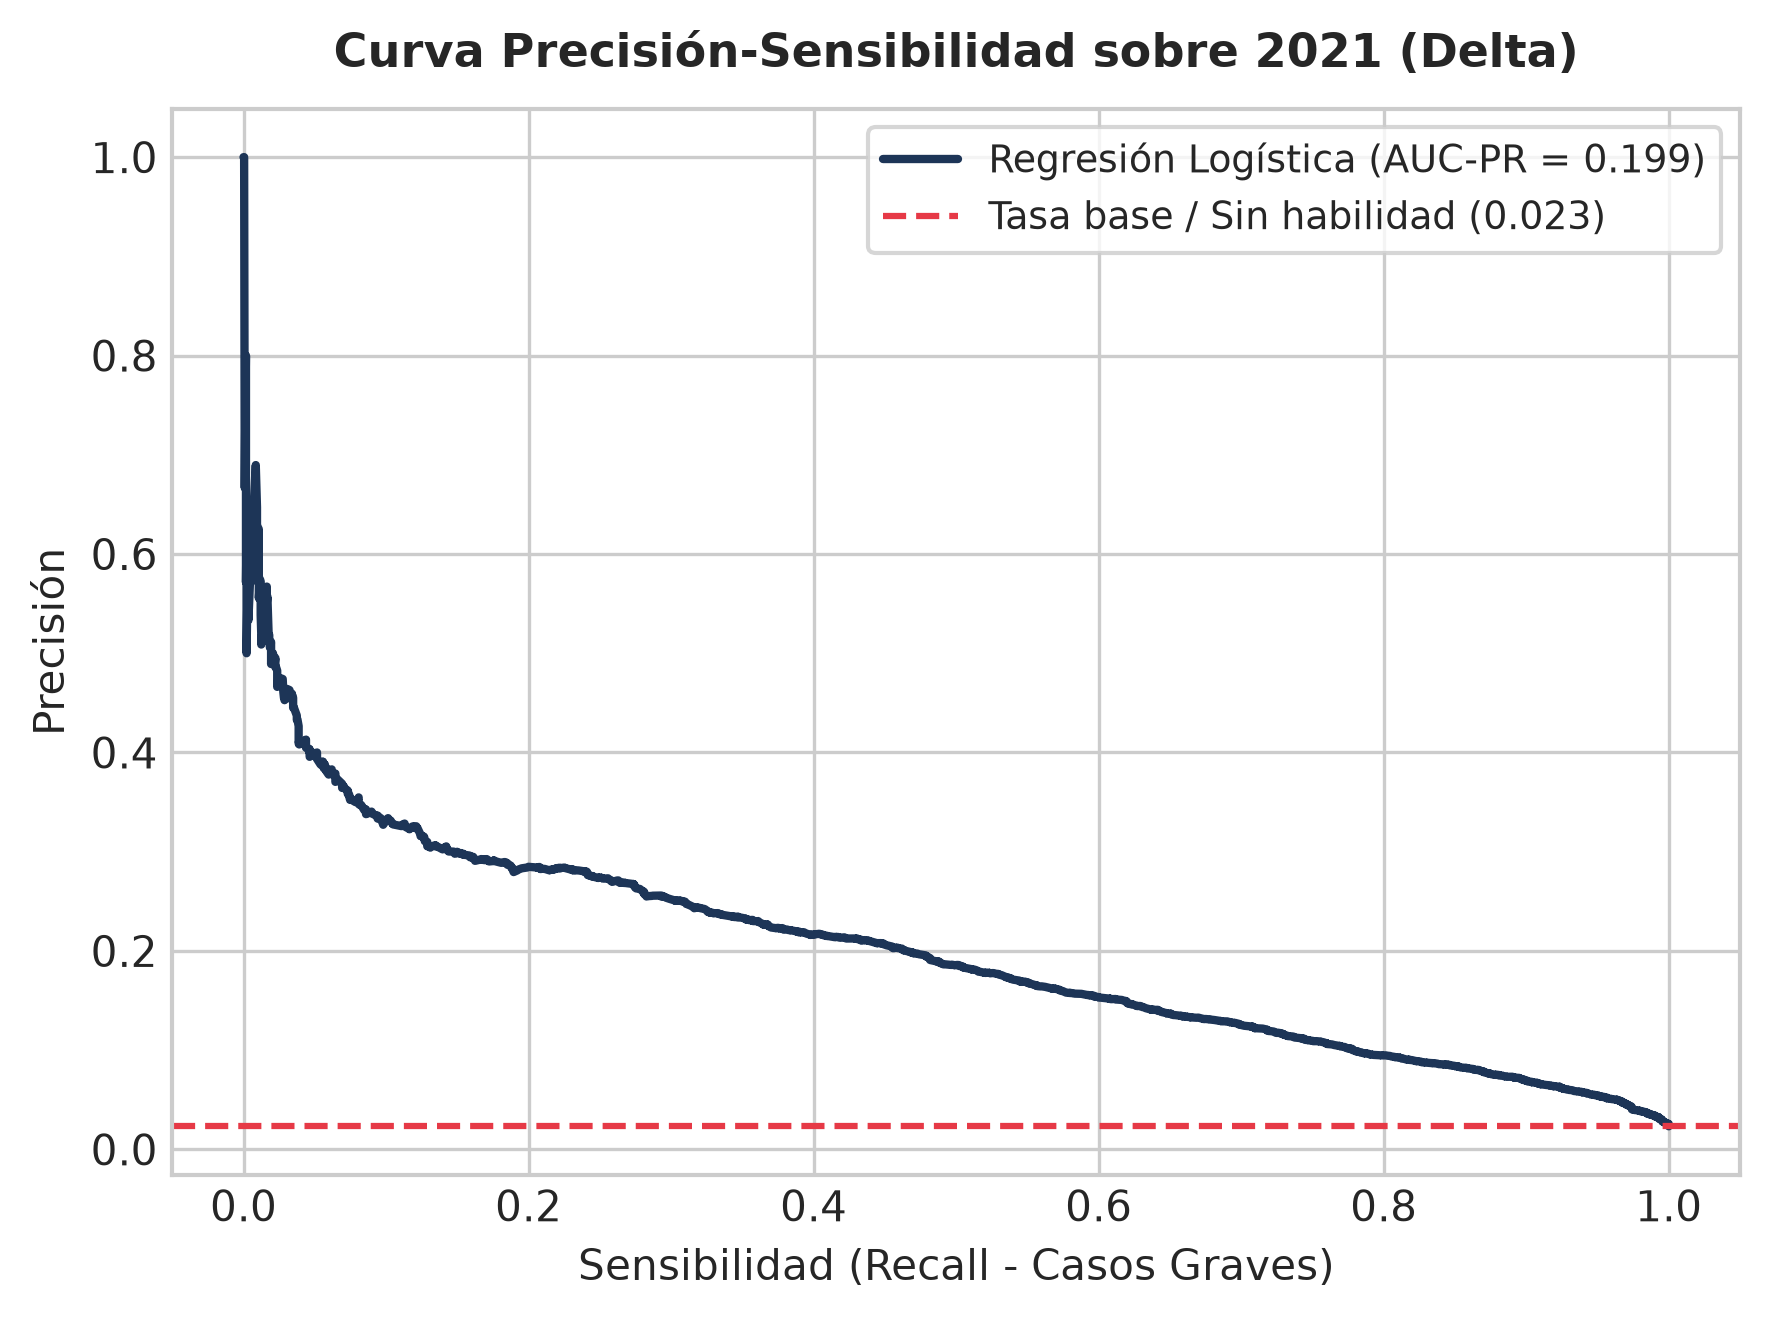

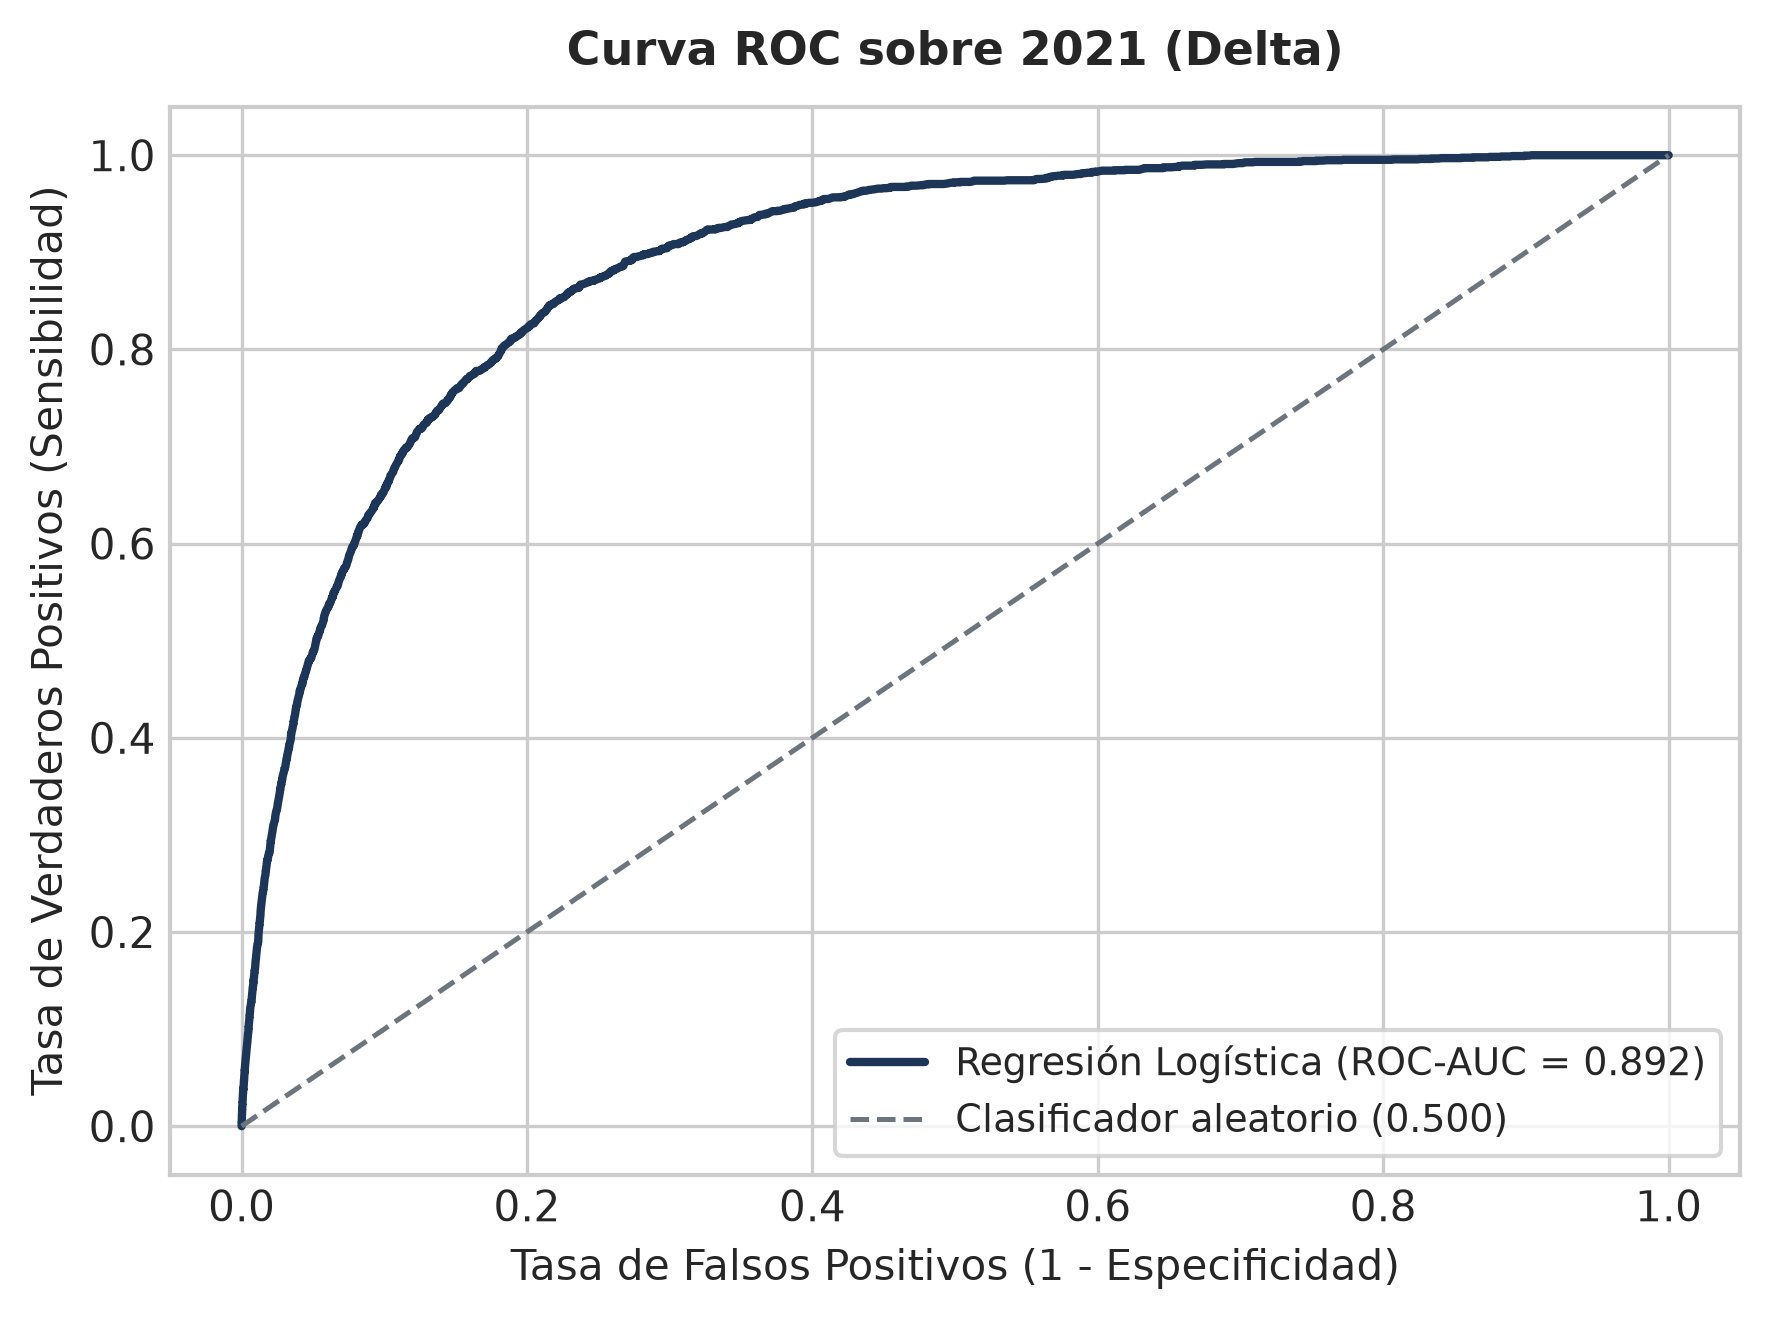

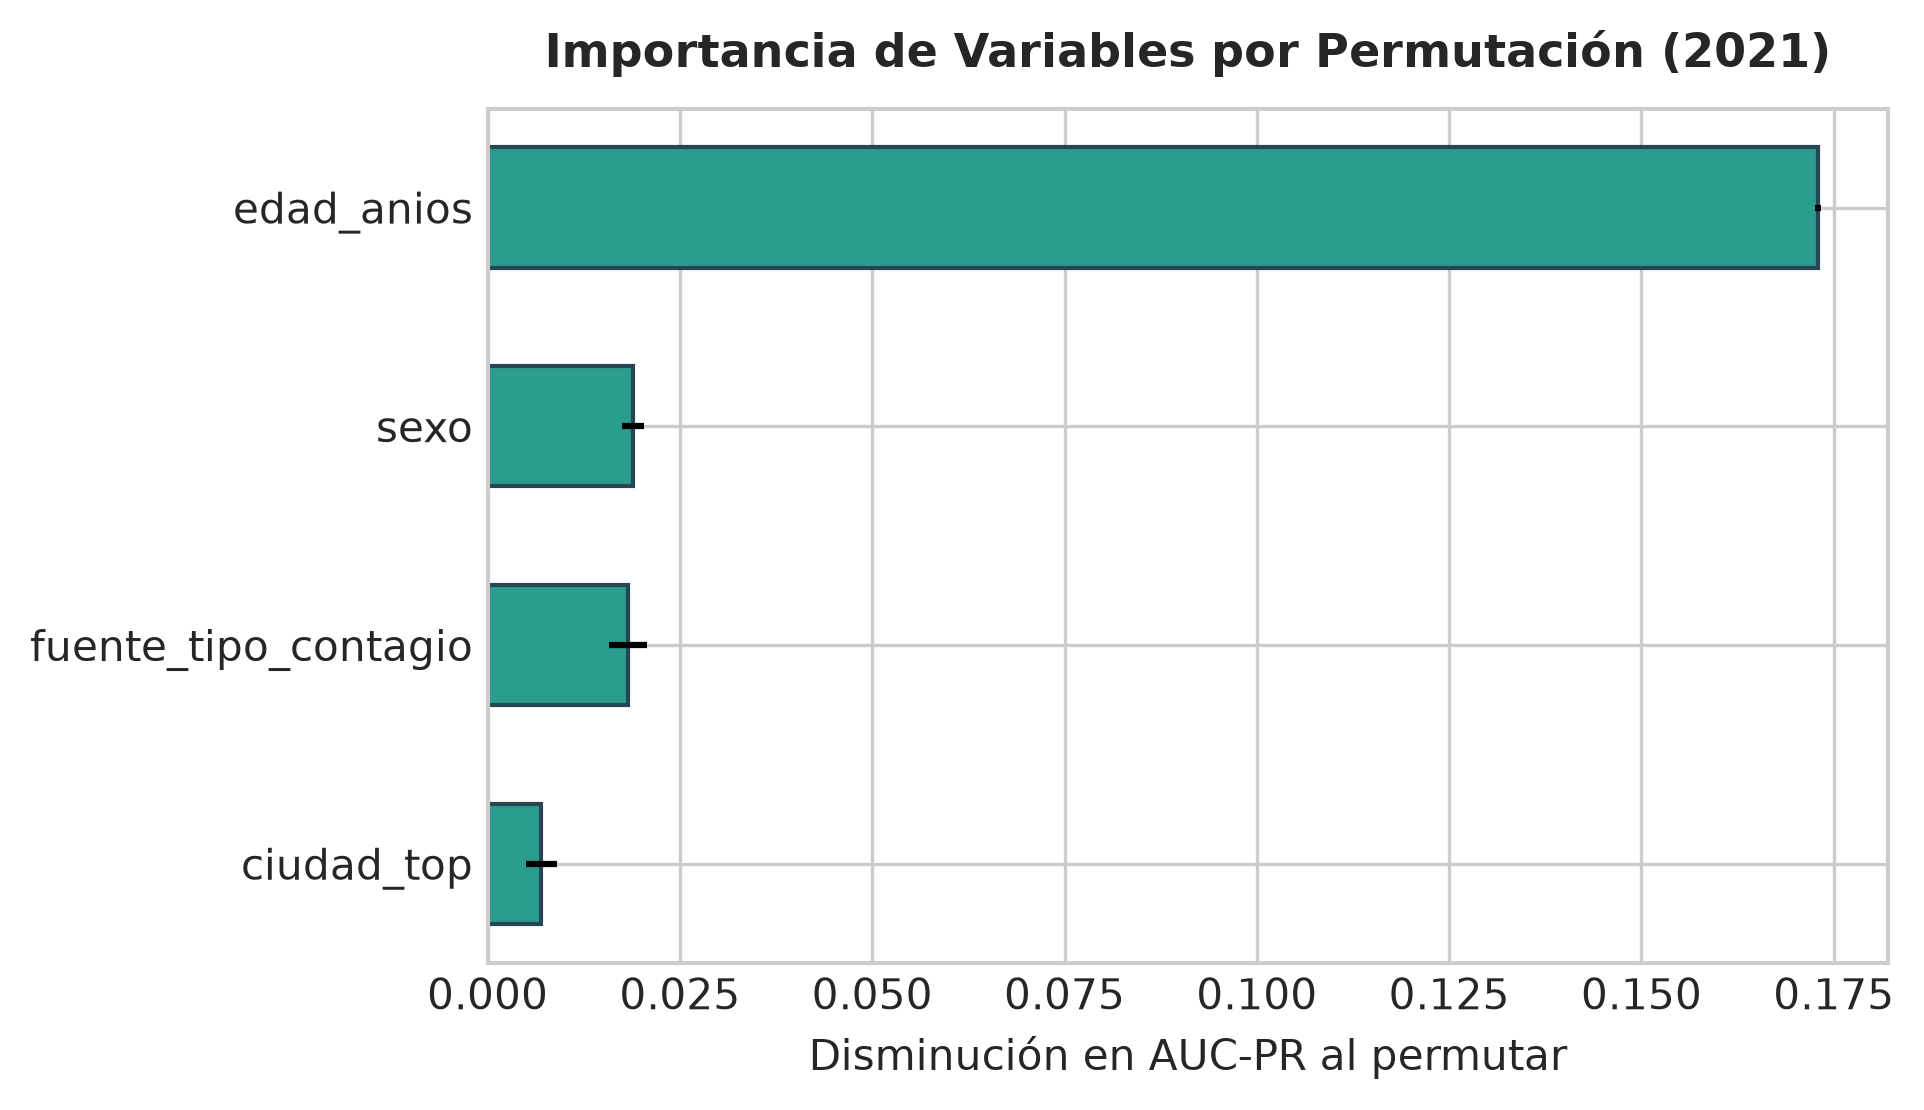


Resumen de Importancia por Permutación (Caída en AUC-PR):
  edad_anios            : 0.1730 +- 0.0004
  sexo                  : 0.0189 +- 0.0015
  ciudad_top            : 0.0070 +- 0.0020
  fuente_tipo_contagio  : 0.0182 +- 0.0025


In [9]:
# --- 9. Interpretación Clínica, Importancia de Variables y Curvas de Desempeño ---
probs_2021 = best_model.predict_proba(X_2021)[:, 1]
prev_2021 = np.mean(y_2021)
ap_2021 = average_precision_score(y_2021, probs_2021)
roc_2021 = roc_auc_score(y_2021, probs_2021)

# 1. Curva PR
pr, rc, _ = precision_recall_curve(y_2021, probs_2021)
fig, ax = plt.subplots(figsize=(6, 4.5), dpi=300)
ax.plot(rc, pr, color='#1d3557', lw=2, label=f'Regresión Logística (AUC-PR = {ap_2021:.3f})')
ax.axhline(prev_2021, color='#e63946', linestyle='--', lw=1.5, label=f'Tasa base / Sin habilidad ({prev_2021:.3f})')
ax.set_xlabel('Sensibilidad (Recall - Casos Graves)', fontsize=10)
ax.set_ylabel('Precisión', fontsize=10)
ax.set_title('Curva Precisión-Sensibilidad sobre 2021 (Delta)', fontsize=11, fontweight='bold', pad=10)
ax.legend(frameon=True, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "curva_pr_2021.png"), dpi=300)
plt.show()

# 2. Curva ROC
fpr, tpr, _ = roc_curve(y_2021, probs_2021)
fig, ax = plt.subplots(figsize=(6, 4.5), dpi=300)
ax.plot(fpr, tpr, color='#1d3557', lw=2, label=f'Regresión Logística (ROC-AUC = {roc_2021:.3f})')
ax.plot([0, 1], [0, 1], color='#6c757d', linestyle='--', lw=1.2, label='Clasificador aleatorio (0.500)')
ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=10)
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=10)
ax.set_title('Curva ROC sobre 2021 (Delta)', fontsize=11, fontweight='bold', pad=10)
ax.legend(frameon=True, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "roc_2021.png"), dpi=300)
plt.show()

# 3. Importancia por Permutación
perm_21 = permutation_importance(best_model, X_2021, y_2021, scoring='average_precision', n_repeats=5, random_state=SEED)
s_idx = np.argsort(perm_21.importances_mean)
fig, ax = plt.subplots(figsize=(6.5, 3.8), dpi=300)
ax.barh(np.array(features)[s_idx], perm_21.importances_mean[s_idx], xerr=perm_21.importances_std[s_idx],
        color='#2a9d8f', edgecolor='#264653', height=0.55)
ax.set_xlabel('Disminución en AUC-PR al permutar', fontsize=10)
ax.set_title('Importancia de Variables por Permutación (2021)', fontsize=11, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "importancia_permutacion.png"), dpi=300)
plt.show()

print("\nResumen de Importancia por Permutación (Caída en AUC-PR):")
for f_name, imp_m, imp_s in zip(features, perm_21.importances_mean, perm_21.importances_std):
    print(f"  {f_name:22s}: {imp_m:.4f} +- {imp_s:.4f}")
